In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
store_df = pd.read_csv('data/store.csv')

train_df = pd.read_csv('data/train.csv', low_memory=False)
    
test_df = pd.read_csv('data/test.csv')

In [12]:
store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [14]:
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [15]:
test_df.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [197]:
df = pd.merge(store_df, train_df, on = 'Store', how = 'right')

In [198]:
df_test = pd.merge(store_df, test_df, on = 'Store', how = 'right')

In [199]:
df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,5,2015-07-31,5263,555,1,1,0,1
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",5,2015-07-31,6064,625,1,1,0,1
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",5,2015-07-31,8314,821,1,1,0,1
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,5,2015-07-31,13995,1498,1,1,0,1
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,5,2015-07-31,4822,559,1,1,0,1


In [200]:
df_test.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Id,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,4,2015-09-17,1.0,1,0,0
1,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2,4,2015-09-17,1.0,1,0,0
2,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN,3,4,2015-09-17,1.0,1,0,0
3,8,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN,4,4,2015-09-17,1.0,1,0,0
4,9,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN,5,4,2015-09-17,1.0,1,0,0


# Cleaning train dataset

In [201]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   StoreType                  1017209 non-null  str    
 2   Assortment                 1017209 non-null  str    
 3   CompetitionDistance        1014567 non-null  float64
 4   CompetitionOpenSinceMonth  693861 non-null   float64
 5   CompetitionOpenSinceYear   693861 non-null   float64
 6   Promo2                     1017209 non-null  int64  
 7   Promo2SinceWeek            509178 non-null   float64
 8   Promo2SinceYear            509178 non-null   float64
 9   PromoInterval              509178 non-null   str    
 10  DayOfWeek                  1017209 non-null  int64  
 11  Date                       1017209 non-null  str    
 12  Sales                      1017209 non-null  int64  
 13  Customers              

In [202]:
df.shape

(1017209, 18)

In [203]:
df.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [204]:
df.isna().sum()

Store                             0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
dtype: int64

### Remove rows when missing values <= 5%

In [205]:
len(df) * 5 /100

50860.45

In [206]:
len(df)

1017209

In [207]:
df.dropna(subset = ['CompetitionDistance'], inplace = True)

In [208]:
df.isna().sum()

Store                             0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth    320706
CompetitionOpenSinceYear     320706
Promo2                            0
Promo2SinceWeek              506147
Promo2SinceYear              506147
PromoInterval                506147
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
dtype: int64

In [209]:
df.duplicated().value_counts()

False    1014567
Name: count, dtype: int64

In [210]:
def split_date(dataframe):
    dataframe['Date'] = pd.to_datetime(dataframe['Date'])
    dataframe['Day'] = dataframe['Date'].dt.day
    dataframe['Month'] = dataframe['Date'].dt.month
    dataframe['Year'] = dataframe['Date'].dt.year
    dataframe['WeekOfYear'] = dataframe['Date'].dt.isocalendar().week

In [211]:
split_date(df)

In [212]:
df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,...,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Day,Month,Year,WeekOfYear
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,...,5263,555,1,1,0,1,31,7,2015,31
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",...,6064,625,1,1,0,1,31,7,2015,31
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",...,8314,821,1,1,0,1,31,7,2015,31
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,...,13995,1498,1,1,0,1,31,7,2015,31
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,...,4822,559,1,1,0,1,31,7,2015,31


In [213]:
df['Date'].min(), df['Date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [214]:
df.groupby('Promo')['PromoInterval'].value_counts()

Promo  PromoInterval   
0      Jan,Apr,Jul,Oct     181550
       Feb,May,Aug,Nov      72878
       Mar,Jun,Sept,Dec     60262
1      Jan,Apr,Jul,Oct     111572
       Feb,May,Aug,Nov      44960
       Mar,Jun,Sept,Dec     37198
Name: count, dtype: int64

In [215]:
def fill_promo_interval(dataframe):
    
    promo_month = {
        'Jan,Apr,Jul,Oct': [1, 4, 7, 10],
        'Feb,May,Aug,Nov': [2, 5, 8, 11],
        'Mar,Jun,Sept,Dec': [3, 6, 9, 12]
    }
    
    def get_interval(month):
        for key, values in promo_month.items():
            if month in values:
                return key
        return np.nan
    
    mask = dataframe['PromoInterval'].isna()
    dataframe.loc[mask, 'PromoInterval'] = dataframe.loc[mask, 'Month'].apply(get_interval)

In [216]:
fill_promo_interval(df)

In [217]:
df.groupby('Promo')['PromoInterval'].value_counts()

Promo  PromoInterval   
0      Jan,Apr,Jul,Oct     291795
       Feb,May,Aug,Nov     172308
       Mar,Jun,Sept,Dec    163390
1      Jan,Apr,Jul,Oct     183034
       Feb,May,Aug,Nov     106124
       Mar,Jun,Sept,Dec     97916
Name: count, dtype: int64

In [218]:
df.isna().sum()

Store                             0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth    320706
CompetitionOpenSinceYear     320706
Promo2                            0
Promo2SinceWeek              506147
Promo2SinceYear              506147
PromoInterval                     0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
Day                               0
Month                             0
Year                              0
WeekOfYear                        0
dtype: int64

In [219]:
df[['CompetitionOpenSinceMonth','CompetitionOpenSinceYear','CompetitionDistance']]

,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,CompetitionDistance
0,9.0,2008.0,1270.0
1,11.0,2007.0,570.0
2,12.0,2006.0,14130.0
3,9.0,2009.0,620.0
4,4.0,2015.0,29910.0
...,...,...,...
1017204,6.0,2014.0,1900.0
1017205,4.0,2006.0,1880.0
1017206,NaN,NaN,9260.0
1017207,NaN,NaN,870.0


In [220]:
min_year = df['Year'].min()
min_month = df['Month'].min()

print(min_year, min_month)

2013 1


In [221]:
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(min_month)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(min_year)

df['CompetitionOpen'] = df['CompetitionOpenSinceYear'] * 12 + df['CompetitionOpenSinceMonth']

In [222]:
df.isna().sum()

Store                             0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth         0
CompetitionOpenSinceYear          0
Promo2                            0
Promo2SinceWeek              506147
Promo2SinceYear              506147
PromoInterval                     0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
Day                               0
Month                             0
Year                              0
WeekOfYear                        0
CompetitionOpen                   0
dtype: int64

In [134]:
df[['Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Promo']]

,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Promo
0,0,NaN,NaN,"Jan,Apr,Jul,Oct",1
1,1,13.0,2010.0,"Jan,Apr,Jul,Oct",1
2,1,14.0,2011.0,"Jan,Apr,Jul,Oct",1
3,0,NaN,NaN,"Jan,Apr,Jul,Oct",1
4,0,NaN,NaN,"Jan,Apr,Jul,Oct",1
...,...,...,...,...,...
1017204,1,31.0,2013.0,"Jan,Apr,Jul,Oct",0
1017205,0,NaN,NaN,"Jan,Apr,Jul,Oct",0
1017206,0,NaN,NaN,"Jan,Apr,Jul,Oct",0
1017207,0,NaN,NaN,"Jan,Apr,Jul,Oct",0


In [223]:
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)

In [224]:
df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,...,Customers,Open,Promo,StateHoliday,SchoolHoliday,Day,Month,Year,WeekOfYear,CompetitionOpen
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,"Jan,Apr,Jul,Oct",...,555,1,1,0,1,31,7,2015,31,24105.0
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",...,625,1,1,0,1,31,7,2015,31,24095.0
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",...,821,1,1,0,1,31,7,2015,31,24084.0
3,4,c,c,620.0,9.0,2009.0,0,0.0,0.0,"Jan,Apr,Jul,Oct",...,1498,1,1,0,1,31,7,2015,31,24117.0
4,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,"Jan,Apr,Jul,Oct",...,559,1,1,0,1,31,7,2015,31,24184.0


In [225]:
df.dtypes

Store                                 int64
StoreType                               str
Assortment                              str
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                           str
DayOfWeek                             int64
Date                         datetime64[us]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                            str
SchoolHoliday                         int64
Day                                   int32
Month                                 int32
Year                                  int32
WeekOfYear                           UInt32
CompetitionOpen                 

In [226]:
df['StateHoliday'].value_counts()

StateHoliday
0    983601
a     20204
b      6672
c      4090
Name: count, dtype: int64

In [227]:
df['StoreType'].value_counts()

StoreType
a    550685
d    311212
c    136840
b     15830
Name: count, dtype: int64

In [228]:
df['Assortment'].value_counts()

Assortment
a    535745
c    470528
b      8294
Name: count, dtype: int64

In [229]:
df['PromoInterval'].value_counts()

PromoInterval
Jan,Apr,Jul,Oct     474829
Feb,May,Aug,Nov     278432
Mar,Jun,Sept,Dec    261306
Name: count, dtype: int64

In [ ]:
categorical_cols = ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']

for col in categorical_cols:
    df[col] = df[col].astype('category')
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
    df = pd.concat([df, dummies], axis=1)
    df.drop(columns = [col], inplace = True)

In [231]:
df.dtypes

Store                                      int64
CompetitionDistance                      float64
CompetitionOpenSinceMonth                float64
CompetitionOpenSinceYear                 float64
Promo2                                     int64
Promo2SinceWeek                          float64
Promo2SinceYear                          float64
DayOfWeek                                  int64
Date                              datetime64[us]
Sales                                      int64
Customers                                  int64
Open                                       int64
Promo                                      int64
SchoolHoliday                              int64
Day                                        int32
Month                                      int32
Year                                       int32
WeekOfYear                                UInt32
CompetitionOpen                          float64
StateHoliday_a                              bool
StateHoliday_b      

In [232]:
df['IsWeekend'] = df['Day'].apply(lambda x: 1 if x in [6, 7] else 0)

In [233]:
df.drop(columns = ['Date', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear'], inplace = True)

In [239]:
df.dtypes

Store                               int64
CompetitionDistance               float64
Promo2                              int64
Promo2SinceWeek                   float64
Promo2SinceYear                   float64
DayOfWeek                           int64
Sales                               int64
Customers                           int64
Open                                int64
Promo                               int64
SchoolHoliday                       int64
Day                                 int32
Month                               int32
Year                                int32
WeekOfYear                         UInt32
CompetitionOpen                   float64
StateHoliday_a                       bool
StateHoliday_b                       bool
StateHoliday_c                       bool
StoreType_b                          bool
StoreType_c                          bool
StoreType_d                          bool
Assortment_b                         bool
Assortment_c                      

In [240]:
from sklearn.preprocessing import StandardScaler

In [241]:
numeric_col = ['CompetitionDistance', 'Promo2SinceWeek', 'Promo2SinceYear', 'Customers']

for col in numeric_col:
    scaler = StandardScaler()
    df[col] = scaler.fit_transform(df[[col]])

In [242]:
df.head()

,Store,CompetitionDistance,Promo2,Promo2SinceWeek,Promo2SinceYear,DayOfWeek,Sales,Customers,Open,Promo,...,StateHoliday_b,StateHoliday_c,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,"PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",IsWeekend
0,1,-0.539198,0,-0.761305,-1.002242,5,5263,-0.169168,1,1,...,False,False,False,True,False,False,False,True,False,0
1,2,-0.629927,1,0.086454,0.996021,5,6064,-0.018516,1,1,...,False,False,False,False,False,False,False,True,False,0
2,3,1.127616,1,0.151667,0.997015,5,8314,0.403309,1,1,...,False,False,False,False,False,False,False,True,False,0
3,4,-0.623446,0,-0.761305,-1.002242,5,13995,1.860326,1,1,...,False,False,False,True,False,False,True,True,False,0
4,5,3.172897,0,-0.761305,-1.002242,5,4822,-0.160559,1,1,...,False,False,False,False,False,False,False,True,False,0


In [243]:
cor_mat = df.corr()

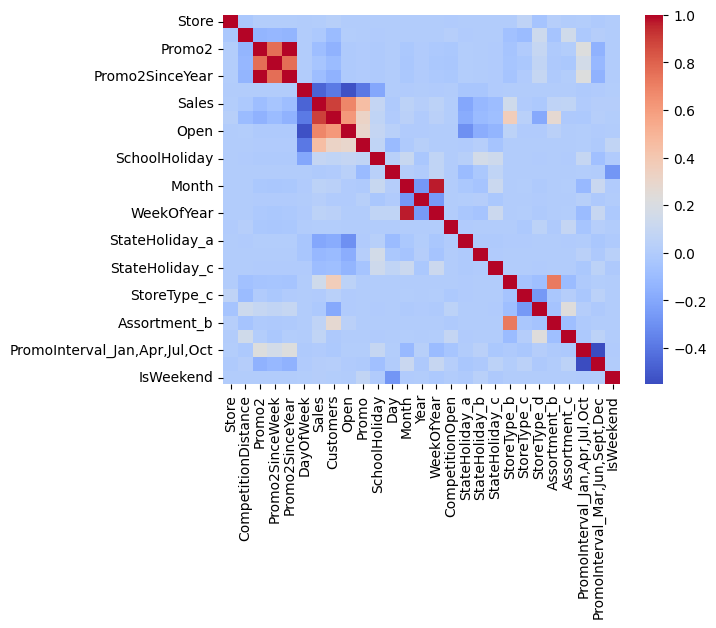

In [244]:
sns.heatmap(cor_mat, fmt = '.2f', cmap = 'coolwarm')
plt.show()

In [245]:
y = df['Sales']
X = df.drop(columns = ['Sales', 'Customers'])

In [246]:
from sklearn.model_selection import train_test_split

In [247]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [253]:
from sklearn.ensemble import RandomForestRegressor

In [254]:
model = RandomForestRegressor(n_estimators=100, max_depth=5)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [255]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [256]:
root_mean_squared_error(y_test, y_pred)

2468.090550953278

In [257]:
mean_squared_error(y_test, y_pred)

6091470.967704857

In [258]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [259]:
importance_df

,feature,importance
6,Open,0.783092
7,Promo,0.123626
5,DayOfWeek,0.026231
17,StoreType_b,0.016790
21,Assortment_c,0.012260
12,WeekOfYear,0.010393
1,CompetitionDistance,0.008440
10,Month,0.006244
13,CompetitionOpen,0.006036
4,Promo2SinceYear,0.004685


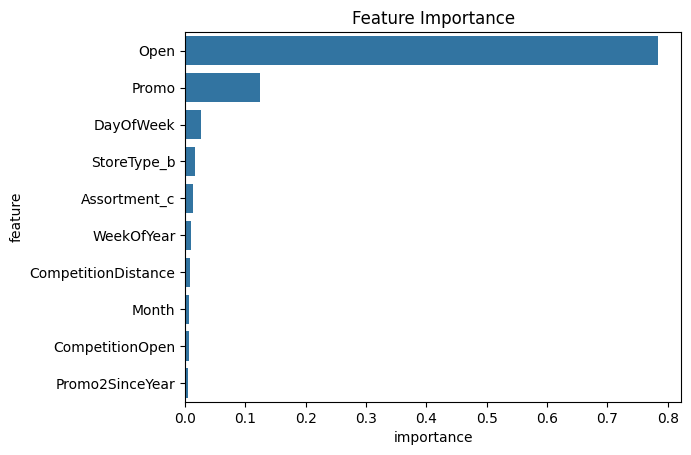

In [261]:
sns.barplot(x = 'importance', y = 'feature', data = importance_df.head(10))
plt.title('Feature Importance')
plt.show()

In [263]:
from sklearn.model_selection import KFold, cross_val_score

In [265]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [266]:
tree = RandomForestRegressor(n_estimators=100, max_depth=5)
scores = cross_val_score(tree, X, y, cv=kfold, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-scores)
print("Cross-validated RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

Cross-validated RMSE scores: [2467.36552319 2457.77752865 2470.47535457 2457.36434561 2463.8746495 ]
Mean RMSE: 2463.3714803051625


In [267]:
from sklearn.metrics import r2_score

In [270]:
r2_score(y_test, y_pred)

0.5889596128599452

In [271]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)
r2_lin = r2_score(y_test, y_pred_lin)
rmse_lin = root_mean_squared_error(y_test, y_pred_lin)

In [272]:
print(f"Linear Regression R2: {r2_lin:.4f}, RMSE: {rmse_lin:.4f}")

Linear Regression R2: 0.5679, RMSE: 2530.5472


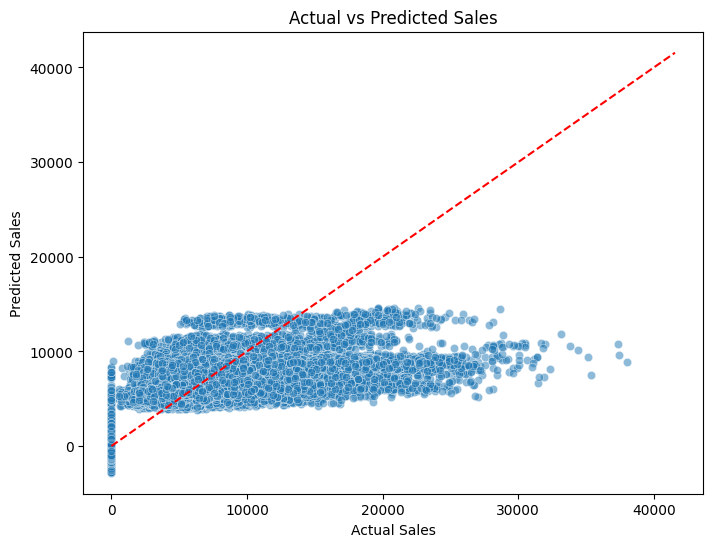

In [274]:
# Plot predicted vs actual values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lin, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()